# <center>**Data Ingestion and Preprocessing**</center>

In [68]:
import yfinance as yf
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import requests
import pyarrow as pa
import pyarrow.parquet as pq
import os
import io # <-- Add this built-in module

In [42]:
# collect data
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
}

response = requests.get(url, headers=headers)

# Wrap the text in io.StringIO() to prevent the FileNotFoundError
table = pd.read_html(io.StringIO(response.text))[0]

tickers = table['Symbol'].str.replace('.', '-').tolist()

print(f"Found {len(tickers)} tickers. Downloading data...")

# Download 8 years of daily data
data = yf.download(
    tickers,
    start="2018-01-01",
    end="2026-06-30",
    auto_adjust=True
)

# In auto_adjust=True mode, 'Close' IS the adjusted close
prices = data[['Close']]

print(prices.shape)  # Should be (~2011, ~500)
prices.to_parquet('data/sp500_raw_prices.parquet')

Found 503 tickers. Downloading data...


[*********************100%***********************]  503 of 503 completed


(2133, 503)


In [43]:
data = pd.read_parquet('data/sp500_raw_prices.parquet')
prices.sample(3)

Price            Close                                                  \
Ticker               A        AAPL        ABBV        ABNB         ABT   
Date                                                                     
2018-01-02   63.400814   40.232376   68.287094         NaN   50.148418   
2022-01-14  139.993149  169.053864  115.648849  163.990005  117.144424   
2022-03-29  133.935974  175.029892  138.043182  175.520004  109.859467   

Price                                                                 ...  \
Ticker           ACGL         ACN        ADBE         ADI        ADM  ...   
Date                                                                  ...   
2018-01-02  27.988113  133.947601  177.699997   77.390305  31.005114  ...   
2022-01-14  45.082100  327.092407  520.599976  159.307083  62.463043  ...   
2022-03-29  46.175632  315.364227  466.329987  158.390625  77.091492  ...   

Price                                                                \
Ticker             WY        WYNN        XEL        XOM         XYL   
Date                                                                  
2018-01-02  25.399536  149.314102  36.876083  57.811153   61.173031   
2022-01-14  34.030960   88.265808  59.612152  61.125854  105.065666   
2022-03-29  33.719727   78.886307  62.517662  70.832809   84.366364   

Price                                                                   
Ticker             XYZ         YUM         ZBH        ZBRA         ZTS  
Date                                                                    
2018-01-02   36.169998   69.837936  112.287773  103.709999   66.351616  
2022-01-14  133.289993  116.584923  118.844849  528.000000  195.147217  
2022-03-29  146.839996  112.664551  124.763351  438.100006  182.283264  

[3 rows x 503 columns]

In [48]:
# drop columns with >5% missing data
prices = prices.loc[:, prices.isna().mean() * 100 <= 5]
prices.shape

(2133, 474)

In [49]:
prices.ffill()

Price            Close                                                \
Ticker               A        AAPL        ABBV        ABT       ACGL   
Date                                                                   
2018-01-02   63.400814   40.232376   68.287094  50.148418  27.988113   
2018-01-03   65.013992   40.225368   69.355713  50.259296  28.013470   
2018-01-04   64.526260   40.412216   68.960167  50.174004  28.118069   
2018-01-05   65.557945   40.872318   70.160637  50.319023  28.007132   
2018-01-08   65.698639   40.720520   69.036507  50.174004  28.010302   
...                ...         ...         ...        ...        ...   
2026-06-23  126.426826  294.046387  233.100815  89.888885  93.709999   
2026-06-24  131.377304  292.827423  233.229904  89.849167  94.919998   
2026-06-25  135.249847  274.912903  241.421585  92.579689  94.330002   
2026-06-26  135.748886  283.535461  251.559433  93.453461  97.540001   
2026-06-29  132.574997  281.497223  252.512650  92.053444  98.059998   

Price                                                                  ...  \
Ticker             ACN        ADBE         ADI        ADM         ADP  ...   
Date                                                                   ...   
2018-01-02  133.947601  177.699997   77.390305  31.005114   96.408806  ...   
2018-01-03  134.565750  181.039993   78.350380  30.765377   97.456078  ...   
2018-01-04  136.159164  183.220001   78.264679  31.283545   98.387024  ...   
2018-01-05  137.282394  185.339996   78.581841  31.074718   98.328827  ...   
2018-01-08  138.379456  185.039993   78.719009  31.005114   98.029610  ...   
...                ...         ...         ...        ...         ...  ...   
2026-06-23  125.500954  197.429993  407.260010  75.361687  220.500000  ...   
2026-06-24  127.615517  196.570007  413.160004  74.606483  219.860001  ...   
2026-06-25  124.325089  193.410004  417.929993  76.057274  216.309998  ...   
2026-06-26  127.447540  202.729996  386.910004  76.305702  223.550003  ...   
2026-06-29  123.257919  206.429993  391.779999  76.385201  224.970001  ...   

Price                                                                 \
Ticker             WY        WYNN        XEL         XOM         XYL   
Date                                                                   
2018-01-02  25.399536  149.314102  36.876083   57.811153   61.173031   
2018-01-03  25.622593  147.696472  36.629276   58.946564   61.918945   
2018-01-04  25.413927  148.496170  36.343895   59.028160   62.332336   
2018-01-05  25.377951  149.486725  36.089363   58.980556   62.215488   
2018-01-08  25.543440  147.496506  36.359306   59.245724   62.440159   
...               ...         ...        ...         ...         ...   
2026-06-23  24.440001  103.895653  80.330002  138.831039  109.981453   
2026-06-24  25.299999  103.496628  81.470001  136.019257  111.615234   
2026-06-25  25.760000   99.137299  81.750000  136.665070  116.556427   
2026-06-26  25.309999  100.194717  82.230003  135.661560  116.008507   
2026-06-29  24.620001   99.177200  81.980003  135.184662  116.287453   

Price                                                                 
Ticker            XYZ         YUM         ZBH        ZBRA        ZTS  
Date                                                                  
2018-01-02  36.169998   69.837936  112.287773  103.709999  66.351616  
2018-01-03  37.310001   69.778038  113.066162  105.769997  66.656693  
2018-01-04  38.099998   70.488403  112.903244  107.860001  67.054260  
2018-01-05  41.139999   70.899200  114.025597  109.540001  67.821564  
2018-01-08  40.759998   71.019028  114.242851  110.629997  68.635139  
...               ...         ...         ...         ...        ...  
2026-06-23  72.370003  151.600006   87.337921  237.720001  76.308060  
2026-06-24  75.680000  153.020004   90.319992  247.779999  77.628853  
2026-06-25  74.080002  151.139999   90.959999  243.389999  77.281281  
2026-06-26  77.820000  156.410004   9

In [60]:
prices.columns = prices.columns.get_level_values('Ticker')
prices = prices.reset_index()
prices.sample(2)

C:\Users\agbad\AppData\Local\Temp\ipykernel_24704\637540955.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  prices = prices.reset_index()


Ticker,Date,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
345,2019-05-17,65.551575,45.170261,58.759258,66.568047,32.121349,159.382065,279.850006,88.638809,32.955975,...,18.481661,113.175217,46.752247,54.969074,68.626068,65.309998,88.984116,106.484329,179.119995,95.178223
1052,2022-03-08,125.130768,153.982483,125.250084,106.130150,41.906097,279.198517,431.529999,138.231155,72.957809,...,33.287643,69.226944,60.666630,75.485039,77.845390,100.620003,106.230255,111.233932,383.920013,171.959427


<Axes: title={'center': 'Raw Stock Prices (Non-Stationary)'}>

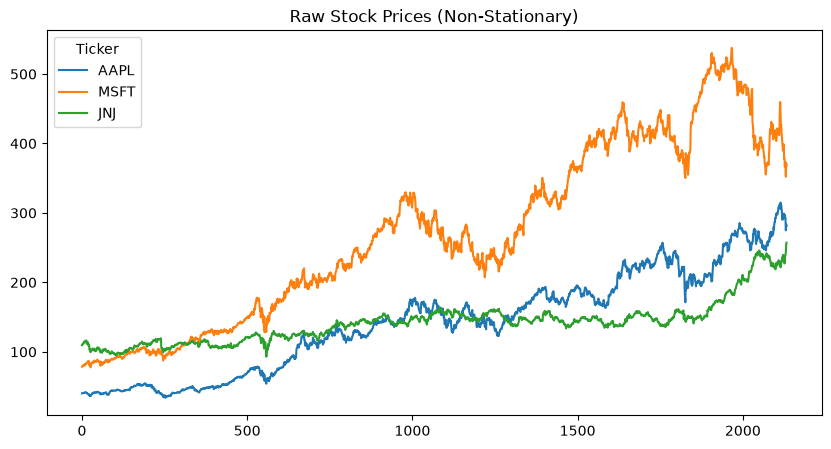

In [65]:
# Diagnostic: Plot raw prices to see the non-stationary trend
prices[['AAPL', 'MSFT', 'JNJ']].plot(figsize=(10, 5), title="Raw Stock Prices (Non-Stationary)")


In [80]:
# compute log returns: Raw prices are non-stationary
# i.e., they drift over time and we cannot do statistics on a time series that has no stable mean
# returns (here log returns) fluctuate around 0 and have a roughly stable distribution over time
returns = np.log(prices.select_dtypes(include='number') / prices.select_dtypes(include='number').shift(1))
returns = returns.dropna(how='all') # drop the first row that became all NaN
returns.insert(0, "Date", prices['Date'])
returns.head()


C:\Users\agbad\AppData\Local\Temp\ipykernel_24704\126331578.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  returns.insert(0, "Date", prices['Date'])


Ticker,Date,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
1,2018-01-03,0.025126,-0.000174,0.015528,0.002209,0.000906,0.004604,0.018621,0.012329,-0.007762,...,0.008744,-0.010893,-0.006715,0.019450,0.012120,0.031031,-0.000858,0.006908,0.019668,0.004587
2,2018-01-04,-0.007530,0.004634,-0.005719,-0.001698,0.003727,0.011772,0.011970,-0.001094,0.016702,...,-0.008177,0.005400,-0.007822,0.001383,0.006654,0.020953,0.010129,-0.001442,0.019567,0.005947
3,2018-01-05,0.015862,0.011321,0.017258,0.002886,-0.003953,0.008216,0.011504,0.004044,-0.006698,...,-0.001417,0.006648,-0.007028,-0.000807,-0.001876,0.076767,0.005811,0.009892,0.015456,0.011378
4,2018-01-08,0.002144,-0.003721,-0.016152,-0.002886,0.000113,0.007960,-0.001620,0.001744,-0.002242,...,0.006500,-0.013403,0.007452,0.004486,0.003605,-0.009280,0.001689,0.001904,0.009901,0.011924
5,2018-01-09,0.024257,-0.000115,0.007510,0.001698,-0.012984,0.003329,0.008931,-0.002071,0.003238,...,-0.006783,0.006755,-0.011736,-0.004255,0.000288,0.002940,-0.002655,-0.016214,0.030183,0.011650


In [82]:
# train test split
formation = returns[returns.Date < "2024-01-01"]
trading = returns[returns.Date >= "2024-01-01"]
print("formation (Training): ", formation.shape)
print("Trading (Backtesting): ", trading.shape)

formation (Training):  (1508, 475)
Trading (Backtesting):  (624, 475)


In [83]:
formation.to_parquet('data/formation.parquet')
trading.to_parquet('data/trading.parquet')